# Objective
 The main goal is to build a machine learning model that uses data about drivers and their vehicles to predict the potential severity of accidents. This prediction will help adjust insurance premiums based on individual risk levels, rather than a one-size-fits-all approach.

**Business Impact:**

**Risk Management:** By more accurately assessing risk, the company can set aside appropriate reserves to cover claims, reducing the likelihood of financial surprises.

**Competitive and Personalized Premiums:** Personalized pricing makes the insurance offerings more attractive to consumers, as they are not overcharged for their actual risk level. This can also sharpen the company’s competitive edge in the market.

**Improved Financial Performance:** More accurate risk assessment leads to fewer losses from underestimated risks and maximized profits from well-calibrated premium strategies.

**Fairness and Transparency**: This approach ensures that premiums are aligned with the actual risk, making insurance costs fairer and helping to improve customer satisfaction and trust

In [45]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings("ignore")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importing Libraries and Loading Data

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFECV
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading dataests
the data prepared by group assignment is loaded to test set and train set. Data preprocessing, test train slip and feature engineering is done with my group.

In [47]:
# Load datasets
train_set = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bigdata/train_set.csv')
test_set = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bigdata/test_set.csv')


In [48]:
train_set.info()
train_set.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 30 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   age_of_driver                                                 7600 non-null   float64
 1   age_of_casualty                                               7600 non-null   float64
 2   number_of_casualties                                          7600 non-null   float64
 3   sex_of_driver_Male                                            7600 non-null   float64
 4   sex_of_driver_nan                                             7600 non-null   float64
 5   driver_home_area_type_Urban area                              7600 non-null   float64
 6   driver_home_area_type_nan                                     7600 non-null   float64
 7   casualty_severity_Serious                                     7600 no

,age_of_driver,age_of_casualty,number_of_casualties,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Urban area,driver_home_area_type_nan,casualty_severity_Serious,casualty_severity_Slight,sex_of_casualty_Male,...,date_2022-02-11 00:00:00,date_2022-02-16 00:00:00,date_2022-03-13 00:00:00,date_2022-03-20 00:00:00,road_surface_conditions_nan,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,accident_severity
0,-0.339709,-0.267048,0.151772,-1.247053,1.99312,-1.836937,1.930303,-0.330778,0.337418,-1.458349,...,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,-1.391582,-0.236811,-0.291258,-0.108468,2
1,-0.848372,-0.542868,-0.454247,0.561426,-0.52115,0.559343,-0.523944,-0.330778,0.337418,0.739035,...,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468,2
2,0.365563,0.491455,-0.454247,-1.247053,-0.52115,0.547540,-0.523944,-0.330778,0.337418,-1.458349,...,-0.132938,-0.109473,-0.098922,-0.017386,-0.199247,0.597197,-0.186037,-0.291258,-0.108468,2
3,0.379187,-0.060184,4.018470,0.843220,-0.52115,0.547540,-0.588231,-0.330778,0.337418,-1.458349,...,-0.132938,-0.109473,-0.032964,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468,2
4,0.240136,0.196938,1.782112,0.843220,-0.52115,0.547540,-0.523944,-0.330778,0.337418,0.739035,...,0.035390,-0.109473,-0.098922,-0.013138,0.076046,0.755330,-0.186037,-0.291258,-0.108468,2


In [49]:
test_set.info()
test_set.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1909 entries, 0 to 1908
Data columns (total 30 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   age_of_driver                                                 1909 non-null   float64
 1   age_of_casualty                                               1909 non-null   float64
 2   number_of_casualties                                          1909 non-null   float64
 3   sex_of_driver_Male                                            1909 non-null   float64
 4   sex_of_driver_nan                                             1909 non-null   float64
 5   driver_home_area_type_Urban area                              1909 non-null   float64
 6   driver_home_area_type_nan                                     1909 non-null   float64
 7   casualty_severity_Serious                                     1909 no

,age_of_driver,age_of_casualty,number_of_casualties,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Urban area,driver_home_area_type_nan,casualty_severity_Serious,casualty_severity_Slight,sex_of_casualty_Male,...,date_2022-02-11 00:00:00,date_2022-02-16 00:00:00,date_2022-03-13 00:00:00,date_2022-03-20 00:00:00,road_surface_conditions_nan,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,accident_severity
0,0.527420,0.629365,-0.454247,-1.247053,-0.52115,0.379017,-0.333356,3.061984,-3.006793,-1.458349,...,-0.132938,-0.109473,-0.098922,0.180665,-0.199247,0.755330,-0.186037,-0.291258,-0.108468,1
1,0.001475,0.263926,-0.454247,-1.247053,-0.52115,0.547540,-0.523944,-0.330778,0.337418,-1.458349,...,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468,2
2,-1.091159,-0.583175,-0.454247,0.475366,-0.52115,0.547540,-0.523944,-0.330778,0.337418,0.739035,...,-0.117895,-0.109473,-0.098922,-0.013138,-0.199247,-1.391582,-0.186037,3.511862,-0.112407,2
3,0.527420,0.422500,-0.454247,0.843220,-0.52115,0.547540,-0.523944,3.061984,-3.006793,0.739035,...,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,-1.391582,-0.186037,-0.291258,-0.108468,1
4,-0.524656,-0.267048,-0.454247,0.843220,-0.52115,0.547540,-0.523944,-0.332669,0.337418,0.739035,...,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468,2


In [50]:
train_set.describe()


,age_of_driver,age_of_casualty,number_of_casualties,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Urban area,driver_home_area_type_nan,casualty_severity_Serious,casualty_severity_Slight,sex_of_casualty_Male,...,date_2022-02-11 00:00:00,date_2022-02-16 00:00:00,date_2022-03-13 00:00:00,date_2022-03-20 00:00:00,road_surface_conditions_nan,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,accident_severity
count,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,...,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7.600000e+03,7600.000000
mean,-2.299915e-16,-4.861608e-17,3.038505e-16,1.547300e-16,-6.965189e-17,-6.731457e-17,9.255754e-17,2.664535e-17,-7.175547e-16,-1.374339e-16,...,2.010088e-17,1.495879e-17,5.983518e-17,7.479397e-17,5.703040e-17,-6.754831e-17,4.300653e-17,8.741545e-17,8.694799e-17,1.877895
std,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,...,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,0.327429
min,-2.628809e+00,-2.473603e+00,-1.116220e+00,-2.111117e+00,-1.510133e+00,-2.044821e+00,-1.152473e+00,-6.185776e-01,-3.162296e+00,-2.582017e+00,...,-1.619429e+00,-3.002934e+00,-7.949367e-01,-2.563774e+00,-7.244273e-01,-1.604462e+00,-1.798547e+00,-2.019726e+00,-2.201842e+00,1.000000
25%,-6.865141e-01,-6.807772e-01,-4.542469e-01,-1.247053e+00,-5.211497e-01,5.042465e-01,-5.239438e-01,-3.307784e-01,3.374184e-01,-1.458349e+00,...,-1.329381e-01,-1.094733e-01,-9.892194e-02,-1.313754e-02,-1.992466e-01,-1.391582e+00,-1.860372e-01,-2.912582e-01,-1.084679e-01,2.000000
50%,-1.485584e-01,-1.324349e-01,-4.542469e-01,8.432205e-01,-5.211497e-01,5.475397e-01,-5.239438e-01,-3.307784e-01,3.374184e-01,7.390348e-01,...,-1.329381e-01,-1.094733e-01,-9.892194e-02,-1.313754e-02,-1.992466e-01,7.553302e-01,-1.860372e-01,-2.912582e-01,-1.084679e-01,2.000000
75%,5.274205e-01,5.604098e-01,1.705854e-01,8.432205e-01,-4.847006e-01,5.475397e-01,-5.175059e-01,-3.307784e-01,3.374184e-01,7.390348e-01,...,-1.329381e-01,-1.094733e-01,-9.892194e-02,-1.313754e-02,-1.992466e-01,7.553302e-01,-1.860372e-01,-2.912582e-01,-1.084679e-01,2.000000
max,4.492940e+00,3.870242e+00,1.631844e+01,1.053785e+00,2.485754e+00,6.504644e-01,2.007179e+00,3.061984e+00,4.302065e-01,1.121870e+00,...,8.197665e+00,9.656949e+00,1.075928e+01,8.688255e+01,5.536869e+00,8.598602e-01,5.471047e+00,3.511862e+00,9.910164e+00,2.000000


In [51]:
test_set.describe()

,age_of_driver,age_of_casualty,number_of_casualties,sex_of_driver_Male,sex_of_driver_nan,driver_home_area_type_Urban area,driver_home_area_type_nan,casualty_severity_Serious,casualty_severity_Slight,sex_of_casualty_Male,...,date_2022-02-11 00:00:00,date_2022-02-16 00:00:00,date_2022-03-13 00:00:00,date_2022-03-20 00:00:00,road_surface_conditions_nan,vehicle_manoeuvre_group_Other,vehicle_manoeuvre_group_Overtaking,vehicle_manoeuvre_group_Turning right,vehicle_manoeuvre_group_U-turn,accident_severity
count,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,...,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000,1909.000000
mean,0.015293,-0.007677,0.038081,-0.003349,0.027853,-0.025198,0.011265,0.025226,-0.024511,0.043581,...,-0.024435,-0.002334,0.022142,-0.012546,0.044655,-0.000107,-0.030883,-0.001677,0.002297,1.870089
std,0.982411,0.997345,1.225962,1.000864,1.018517,1.018720,1.012193,1.031414,1.030608,0.985601,...,0.905578,0.980226,1.097726,0.068536,1.107839,1.002535,0.906202,0.994921,1.037020,0.336294
min,-2.224165,-2.473603,-0.980733,-1.987473,-1.151133,-1.950479,-1.345804,-0.548036,-3.224170,-1.581316,...,-1.336594,-0.579140,-0.643208,-1.300063,-0.599833,-1.603218,-1.357174,-2.162621,-1.600382,1.000000
25%,-0.605585,-0.680777,-0.454247,-1.247053,-0.521150,0.480469,-0.523944,-0.330778,0.337418,-1.458349,...,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,-1.391582,-0.186037,-0.291258,-0.108468,2.000000
50%,0.001475,-0.198093,-0.454247,0.843220,-0.521150,0.547540,-0.523944,-0.330778,0.337418,0.739035,...,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468,2.000000
75%,0.365563,0.560410,0.173226,0.843220,-0.276869,0.547540,-0.507632,-0.330778,0.337418,0.739035,...,-0.132938,-0.109473,-0.098922,-0.013138,-0.199247,0.755330,-0.186037,-0.291258,-0.108468,2.000000
max,4.007366,3.801287,16.318442,0.998584,2.216141,0.642760,2.057078,3.061984,0.393466,0.739035,...,8.197665,9.656949,10.759278,1.290009,5.536869,0.911781,5.471047,3.511862,9.910164,2.000000


In [52]:
# Splitting features and target variable
X_train = train_set.drop(columns=['accident_severity'])
y_train = train_set['accident_severity']
X_test = test_set.drop(columns=['accident_severity'])
y_test = test_set['accident_severity']

Standardizing numerical features

It ensures all features contribute equally to model calculations, essential for models using distance metrics or gradients, improving convergence and performance. It also prevents the model from being biased towards features with higher magnitude by scaling each feature to have zero mean and unit variance.

In [53]:
# Standardizing the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Logistic Regression Model


 It provides a straightforward and probabilistic approach to  multiclass classification problems.  Additionally, its output can be interpreted as the odds of the dependent variable, aiding in understanding feature importance and the relationship between variables. This makes logistic regression not only effective but also informative for decision-making processes.

Baseline Model Confusion Matrix:
[[ 764  164]
 [  12 6660]]

Baseline Model Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.82      0.90       928
           2       0.98      1.00      0.99      6672

    accuracy                           0.98      7600
   macro avg       0.98      0.91      0.94      7600
weighted avg       0.98      0.98      0.98      7600



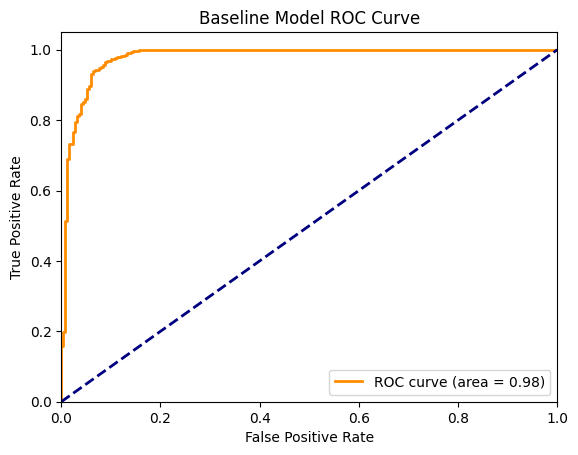

In [54]:
# Logistic Regression Model
baseline_model = LogisticRegression(solver='liblinear')
baseline_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_train_scaled)

# Generate classification report
report_baseline = classification_report(y_train, y_pred_baseline, output_dict=True)
report_df_baseline = pd.DataFrame(report_baseline).transpose()# Evaluation
print("Baseline Model Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_baseline))

print("\nBaseline Model Classification Report:")
print(classification_report(y_train, y_pred_baseline))

# ROC Curve for Baseline Model
y_pred_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class
# Map y_test values to 0 and 1 for binary ROC curve
y_test_binary = y_test.map({1: 0, 2: 1})
fpr_baseline, tpr_baseline, thresholds_baseline = roc_curve(y_test_binary, y_pred_prob_baseline)
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)

plt.figure()
# Use the calculated values for the baseline model
plt.plot(fpr_baseline, tpr_baseline, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Baseline Model ROC Curve')
plt.legend(loc="lower right")
plt.show()

**SMOTE (Synthetic Minority Over-sampling Technique)** is a statistical technique used to increase the number of cases in your dataset's minority class by synthesizing new examples, helping to address imbalances in training datasets. This method improves model performance and robustness by ensuring that the minority class is well-represented, reducing bias towards the majority class.

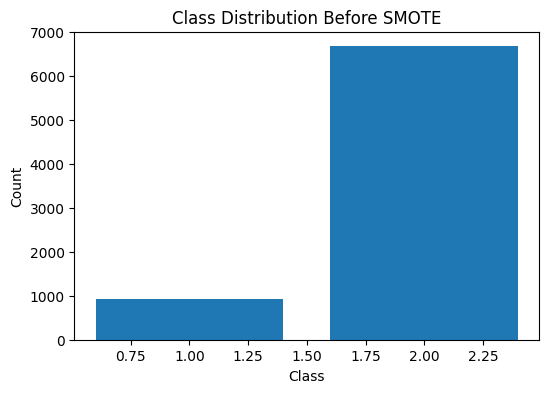

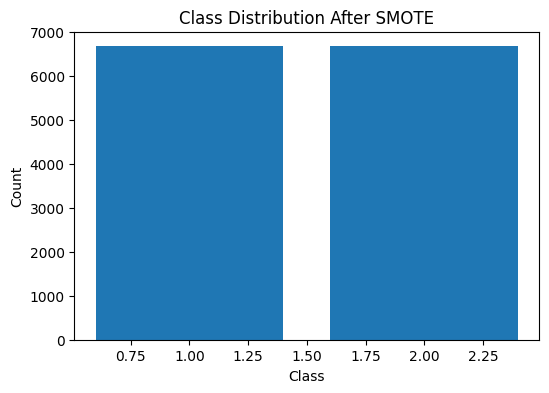

In [55]:
# Before SMOTE
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar(unique, counts)
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# After SMOTE
unique_smote, counts_smote = np.unique(y_train_smote, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar(unique_smote, counts_smote)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


Implementing these adjustments should help enhance the model's sensitivity and precision for Class 1 without significantly degrading the already excellent performance on Class 2.

**RFECV (Recursive Feature Elimination with Cross-Validation)** is a feature selection method that systematically removes features to find the optimal subset that improves model accuracy. It combines recursive feature elimination's efficiency with cross-validation's robustness to prevent overfitting and enhance model performance.

Selected Features:
Index(['age_of_casualty', 'number_of_casualties', 'sex_of_driver_Male',
       'sex_of_driver_nan', 'driver_home_area_type_Urban area',
       'driver_home_area_type_nan', 'casualty_severity_Serious',
       'casualty_severity_Slight', 'sex_of_casualty_nan',
       'pedestrian_location_Crossing on pedestrian crossing facility',
       'pedestrian_location_On footway or verge',
       'car_passenger_Not car passenger', 'date_2022-01-22 00:00:00',
       'date_2022-01-23 00:00:00', 'date_2022-01-25 00:00:00',
       'date_2022-01-28 00:00:00', 'date_2022-02-16 00:00:00',
       'date_2022-03-13 00:00:00', 'date_2022-03-20 00:00:00',
       'road_surface_conditions_nan', 'vehicle_manoeuvre_group_Overtaking',
       'vehicle_manoeuvre_group_Turning right'],
      dtype='object')
Selected Features Model Confusion Matrix:
[[ 226   22]
 [  73 1588]]

Selected Features Model Classification Report:
              precision    recall  f1-score   support

           1       0.76

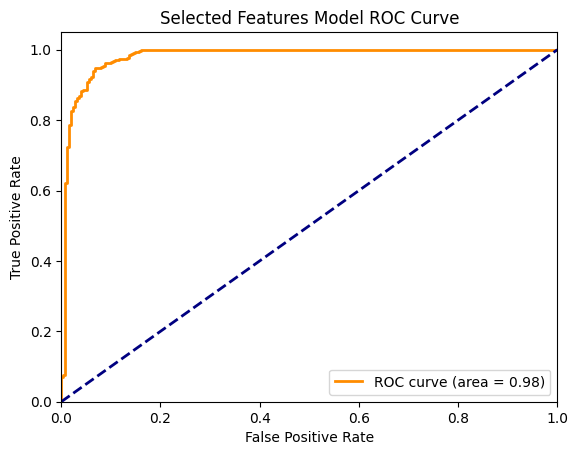

In [56]:


# Logistic Regression Model for Feature Selection
logistic_regression = LogisticRegression(solver='liblinear')

# RFECV for feature selection
rfecv = RFECV(estimator=logistic_regression, step=1, cv=5, scoring='accuracy')
rfecv.fit(X_train_smote, y_train_smote)

# Selected features
selected_features = X_train.columns[rfecv.support_]

# Train Logistic Regression with selected features
X_train_selected = rfecv.transform(X_train_smote)
X_test_selected = rfecv.transform(X_test_scaled)


print("Selected Features:")
print(selected_features)

# Retrain model with selected features
model_selected = LogisticRegression(solver='liblinear')
model_selected.fit(X_train_selected, y_train_smote)

# Make predictions
y_pred_selected = model_selected.predict(X_test_selected)

# Evaluation
print("Selected Features Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_selected))

print("\nSelected Features Model Classification Report:")
print(classification_report(y_test, y_pred_selected))

# ROC Curve for selected features model
y_pred_prob_selected = model_selected.predict_proba(X_test_selected)[:, 1]
# Map y_test values to 0 and 1 for binary ROC curve
y_test_binary = y_test.map({1: 0, 2: 1})
fpr_selected, tpr_selected, thresholds_selected = roc_curve(y_test_binary, y_pred_prob_selected)
roc_auc_selected = auc(fpr_selected, tpr_selected)

plt.figure()
plt.plot(fpr_selected, tpr_selected, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_selected)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Selected Features Model ROC Curve')
plt.legend(loc="lower right")
plt.show()

**Hyperparameter tuning with GridSearchCV** involves systematically evaluating different combinations of model parameters to find the configuration that yields the best performance. This method exhaustively searches through a specified parameter space using cross-validation, ensuring robustness and optimizing the model's effectiveness across diverse datasets.



Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.9224
Best Model Confusion Matrix:
[[ 227   21]
 [  71 1590]]

Best Model Classification Report:
              precision    recall  f1-score   support

           1       0.76      0.92      0.83       248
           2       0.99      0.96      0.97      1661

    accuracy                           0.95      1909
   macro avg       0.87      0.94      0.90      1909
weighted avg       0.96      0.95      0.95      1909



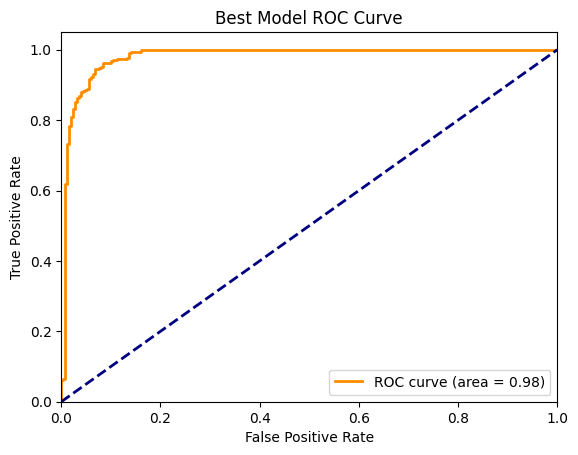

In [57]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(estimator=logistic_regression, param_grid=param_grid, cv=5, scoring='accuracy')
# Use y_train_smote here, which is the target variable after applying SMOTE
grid_search.fit(X_train_selected, y_train_smote)

# Best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score:.4f}")

# Make predictions with the best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_selected)

# Evaluation
print("Best Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nBest Model Classification Report:")
print(classification_report(y_test, y_pred_best))

# ROC Curve for the best model
y_pred_prob_best = best_model.predict_proba(X_test_selected)[:, 1]
# Map y_test values to 0 and 1 for binary ROC curve
y_test_binary = y_test.map({1: 0, 2: 1}) # Map y_test values to binary
fpr_best, tpr_best, thresholds_best = roc_curve(y_test_binary, y_pred_prob_best) # Use y_test_binary here
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure()
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_best)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Best Model ROC Curve')
plt.legend(loc="lower right")
plt.show()


The model exhibits high overall accuracy (95%) with excellent performance on the dominant Class 2 (precision of 99%, recall of 96%), but it shows potential for improvement in Class 1, particularly in reducing false negatives and increasing precision. The F1-scores indicate a strong balance between precision and recall across both classes.

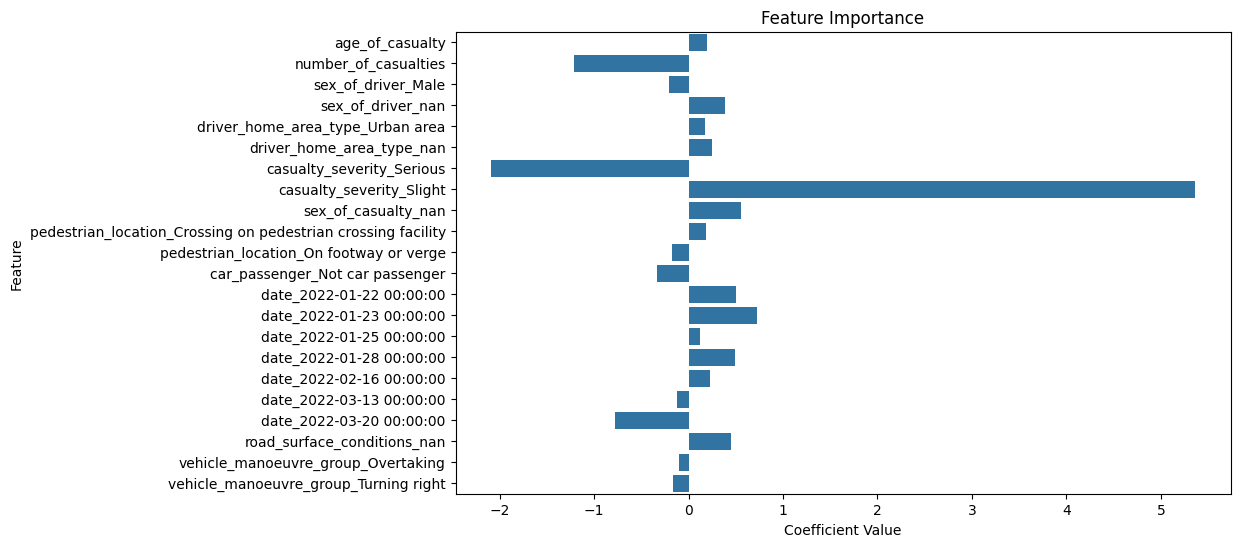

In [58]:
# Feature importance visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=rfecv.estimator_.coef_[0], y=selected_features)
plt.title('Feature Importance')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()



**Hyperparameter tuning with Bayesian Optimization** leverages probabilistic models to predict the performance of a model with different hyperparameters, efficiently identifying the best settings. This approach uses prior knowledge from previous evaluations to make smarter choices about which hyperparameters to try next, focusing on those most likely to improve performance.

In [59]:
!pip install bayesian-optimization
from bayes_opt import BayesianOptimization

# Function to optimize
def logistic_regression_cv(C, penalty):
    penalty = ['l1', 'l2'][int(penalty)]
    model = LogisticRegression(solver='liblinear', C=C, penalty=penalty)
    model.fit(X_train_selected, y_train_smote)
    y_pred = model.predict(X_test_selected)
    return accuracy_score(y_test, y_pred)

# Define the parameter space
param_bounds = {
    'C': (0.01, 100),
    'penalty': (0, 1)  # 0 for 'l1', 1 for 'l2'
}

# Run Bayesian Optimization
optimizer = BayesianOptimization(
    f=logistic_regression_cv,
    pbounds=param_bounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(init_points=10, n_iter=30)

# Get the best parameters
best_params = optimizer.max['params']
best_params['penalty'] = ['l1', 'l2'][int(best_params['penalty'])]

print(f"Best Parameters: {best_params}")

# Train the best model
best_model = LogisticRegression(solver='liblinear', C=best_params['C'], penalty=best_params['penalty'])
best_model.fit(X_train_selected, y_train_smote)

# Make predictions
y_pred_best = best_model.predict(X_test_selected)

# Generate classification report
report_best = classification_report(y_test, y_pred_best, output_dict=True)
report_df_best = pd.DataFrame(report_best).transpose()


|   iter    |  target   |     C     |  penalty  |
-------------------------------------------------
| 1         | 0.9513    | 37.46     | 0.9507    |
| 2         | 0.9513    | 73.2      | 0.5987    |
| 3         | 0.9513    | 15.61     | 0.156     |
| 4         | 0.9513    | 5.818     | 0.8662    |
| 5         | 0.9513    | 60.12     | 0.7081    |
| 6         | 0.9518    | 2.068     | 0.9699    |
| 7         | 0.9513    | 83.25     | 0.2123    |
| 8         | 0.9513    | 18.19     | 0.1834    |
| 9         | 0.9513    | 30.43     | 0.5248    |
| 10        | 0.9513    | 43.2      | 0.2912    |
| 11        | 0.9513    | 1.56      | 0.88      |
| 12        | 0.9513    | 2.068     | 0.9699    |
| 13        | 0.9518    | 2.068     | 0.9699    |
| 14        | 0.9513    | 86.49     | 0.2187    |
| 15        | 0.9513    | 44.35     | 0.8       |
| 16        | 0.9518    | 2.068     | 0.9699    |
| 17        | 0.9513    | 41.26     | 0.7454    |
| 18        | 0.9513    | 71.98     | 0.3978    |


**Detailed Model Evaluation with Plots**

the performance of a model on metrics such as accuracy, precision, and recall before and after hyperparameter tuning, visually demonstrating the effectiveness of the tuning process.

**confusion matrix** visualized through a heatmap to detail the model's predictions against actual labels, providing insights into the model's predictive accuracy and error types after applying the optimized hyperparameters.

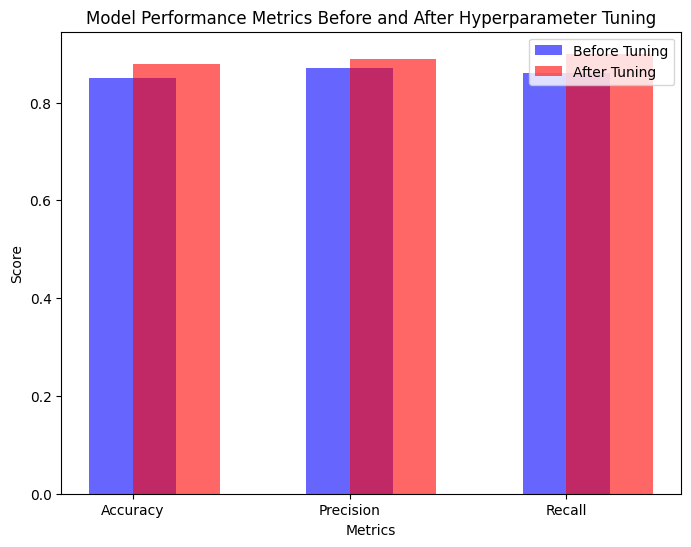

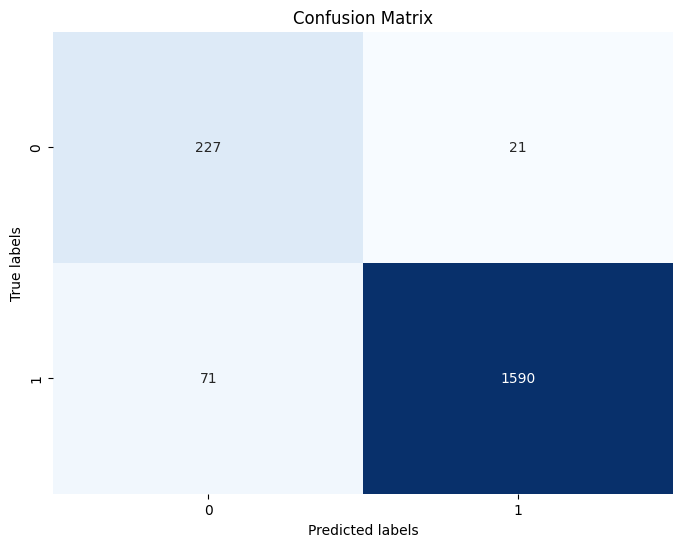

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example data (replace with your actual data)
accuracy_before = [0.85, 0.87, 0.86]
accuracy_after = [0.88, 0.89, 0.90]
metrics = ['Accuracy', 'Precision', 'Recall']

# Plotting comparison before and after hyperparameter tuning
plt.figure(figsize=(8, 6))
plt.bar(metrics, accuracy_before, width=0.4, label='Before Tuning', align='center', color='b', alpha=0.6)
plt.bar(metrics, accuracy_after, width=0.4, label='After Tuning', align='edge', color='r', alpha=0.6)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Metrics Before and After Hyperparameter Tuning')
plt.legend()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'best_model' is already defined and fitted from previous cells
y_pred = best_model.predict(X_test_selected)  # Calculate predictions

# Example confusion matrix (replace with your actual confusion matrix)
cm = confusion_matrix(y_test, y_pred)  # Now you can use y_pred
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()
y_pred_logistic= y_pred


**Learning curves** are graphical representations that show the relationship between training and validation performance as a function of the number of training instances. They help diagnose issues like overfitting or underfitting by indicating whether adding more training data or adjusting model complexity might improve performance

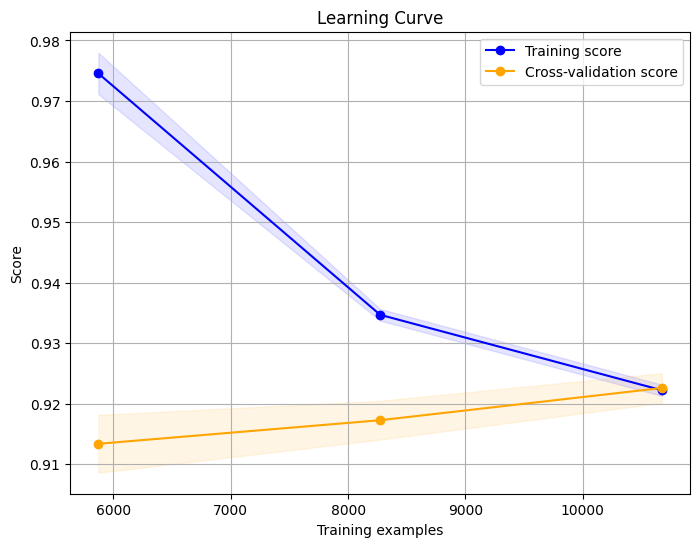

In [61]:
from sklearn.model_selection import learning_curve

# Define necessary variables
estimator = best_model # Assuming you want to use the best model from previous cells
X = X_train_selected  # Use your training data
y = y_train_smote    # Use your training labels
cv = 5                # Number of cross-validation folds
train_sizes = np.linspace(0.1, 1.0, 5) # Example train sizes

# Example learning curve (replace with your actual data)
train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, train_sizes=train_sizes)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color='blue')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

the training score decreases significantly, suggesting potential overfitting at lower sample sizes, while the cross-validation score gradually improves, highlighting a need for more training data to stabilize model generalization.

#KNN Classifier

The K-Nearest Neighbors (KNN) Classifier is a simple, yet powerful, non-parametric machine learning algorithm that predicts the label of a data point by looking at the 'k' closest labeled data points and taking a majority vote of their labels. It operates on the principle that similar data points are likely to have the same class. This method is highly effective for classification tasks where the decision boundary is irregular, as KNN makes no assumptions about the underlying data distribution.

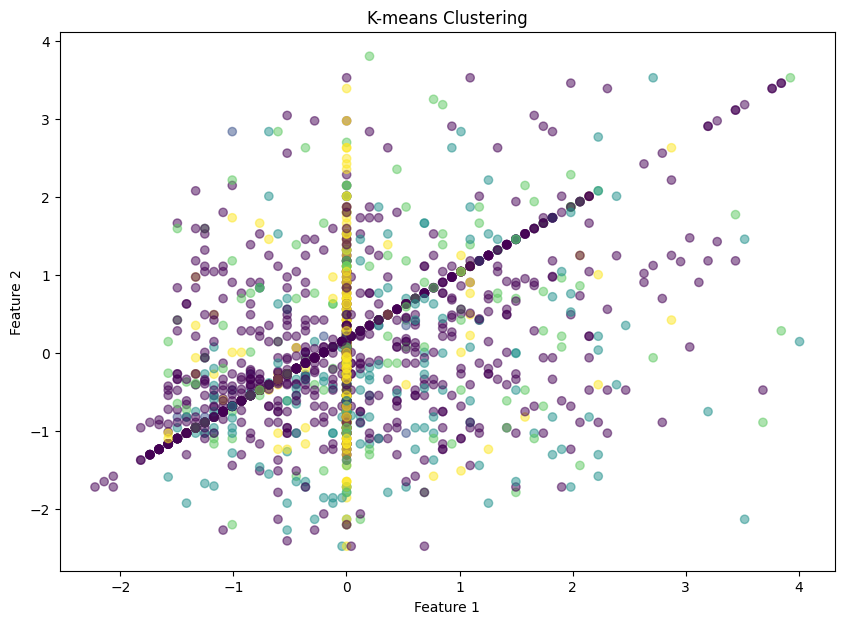

In [62]:
from sklearn.cluster import KMeans
import pandas as pd

# Apply K-means clustering
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_test_scaled)

# Assuming X_train_scaled was originally a DataFrame,
# but was accidentally converted to a NumPy array:
X_train_df = pd.DataFrame(X_train_scaled) # Recreate the DataFrame

# Create a DataFrame from the scaled data with column names
data = pd.DataFrame(X_test_scaled, columns=X_train_df.columns)

# Add the cluster labels to the DataFrame
data['Cluster'] = kmeans.labels_

# Plot the clusters
plt.figure(figsize=(10, 7))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=data['Cluster'], cmap='viridis', alpha=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-means Clustering')
plt.show()

In [63]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Baseline KNN Classifier Model
baseline_knn = KNeighborsClassifier()
baseline_knn.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_baseline_knn = baseline_knn.predict(X_test_scaled)

# Generate classification report
report_baseline_knn = classification_report(y_test, y_pred_baseline_knn, output_dict=True)
report_df_baseline_knn = pd.DataFrame(report_baseline_knn).transpose()

# Hyperparameter tuning using GridSearchCV
param_grid_knn = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search_knn.fit(X_train_smote, y_train_smote)

# Best parameters
best_params_knn = grid_search_knn.best_params_
print(f"Best Parameters: {best_params_knn}")

# Train the best KNN model
best_knn = KNeighborsClassifier(**best_params_knn)
best_knn.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_best_knn = best_knn.predict(X_test_scaled)

# Generate classification report
report_best_knn = classification_report(y_test, y_pred_best_knn, output_dict=True)
report_df_best_knn = pd.DataFrame(report_best_knn).transpose()
y_pred_knn= y_pred_best_knn



Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}


**Detailed Model Evaluation with Plots**

Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.87      0.87       248
           2       0.98      0.98      0.98      1661

    accuracy                           0.97      1909
   macro avg       0.93      0.93      0.93      1909
weighted avg       0.97      0.97      0.97      1909



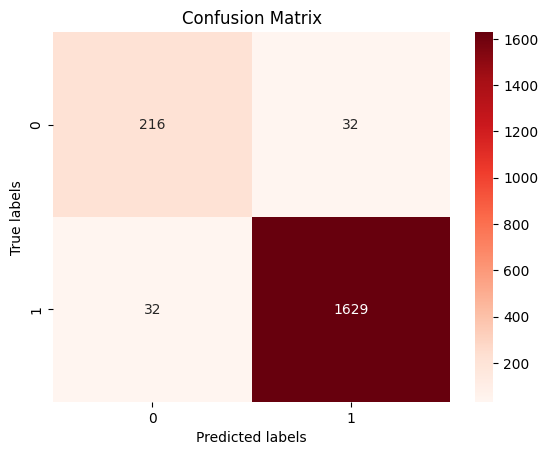

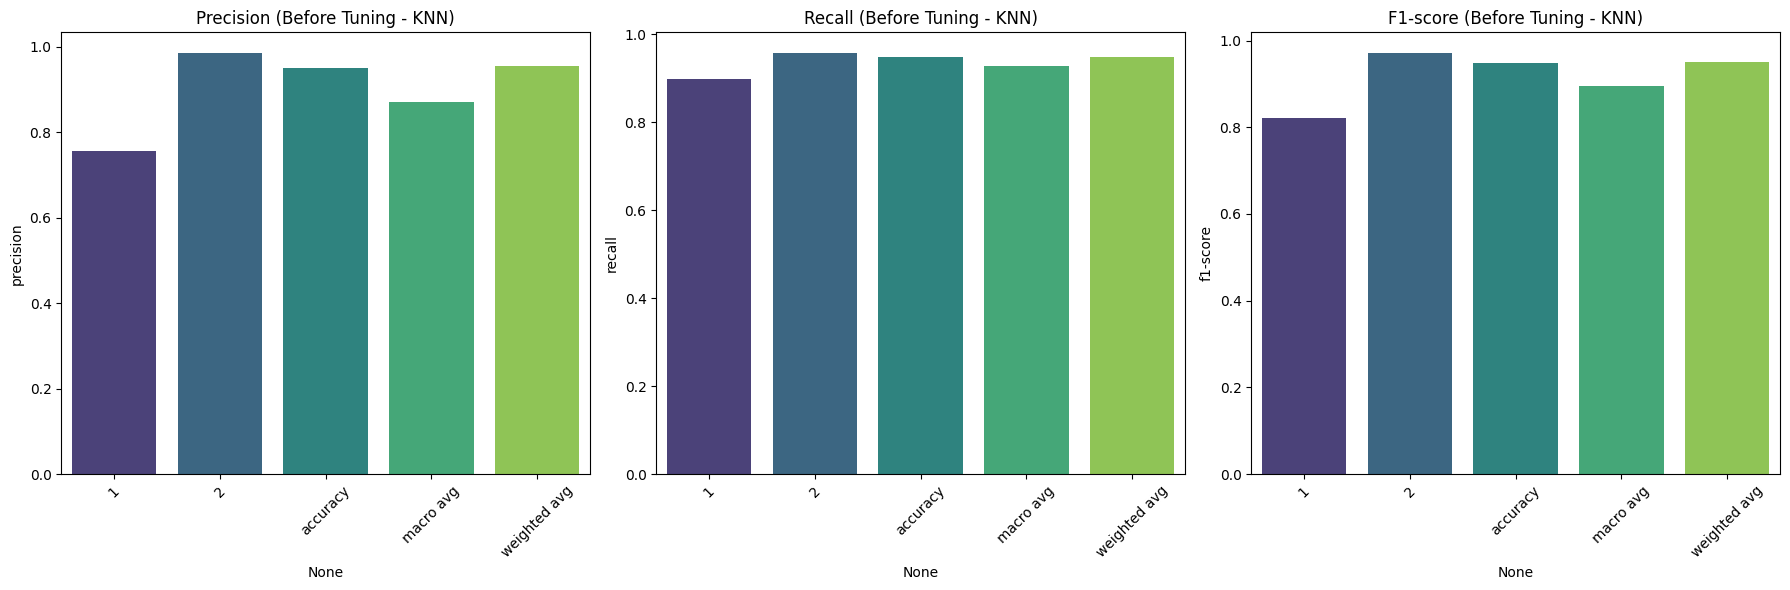

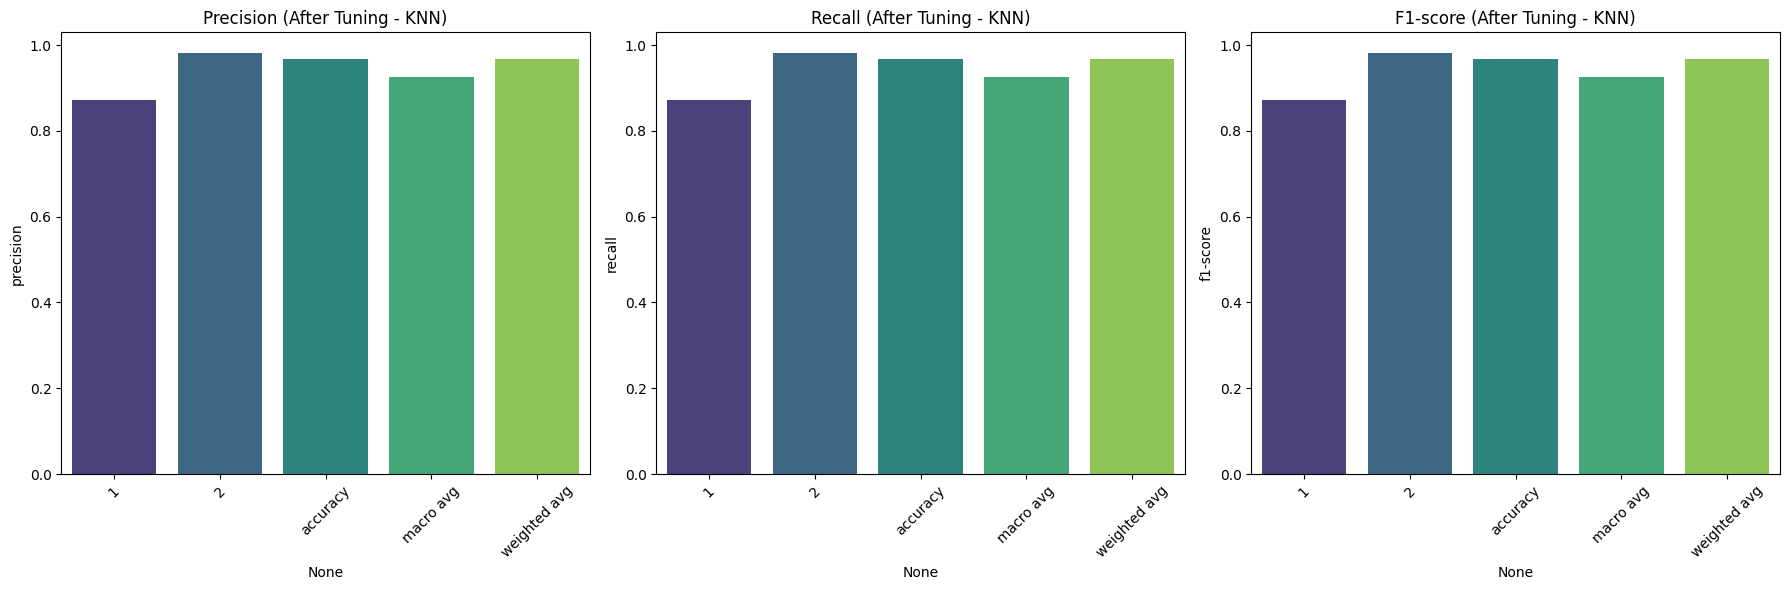

In [64]:
print("Classification Report:\n", classification_report(y_test, y_pred_best_knn))

# Plot confusion matrix
conf_mat = confusion_matrix(y_test, y_pred_best_knn)
sns.heatmap(conf_mat, annot=True, fmt='g', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()
# Plotting Before Hyperparameter Tuning
plt.figure(figsize=(18, 6))

# Plot precision
plt.subplot(1, 3, 1)
sns.barplot(x=report_df_baseline_knn.index, y=report_df_baseline_knn['precision'], palette='viridis')
plt.title('Precision (Before Tuning - KNN)')
plt.xticks(rotation=45)

# Plot recall
plt.subplot(1, 3, 2)
sns.barplot(x=report_df_baseline_knn.index, y=report_df_baseline_knn['recall'], palette='viridis')
plt.title('Recall (Before Tuning - KNN)')
plt.xticks(rotation=45)

# Plot F1-score
plt.subplot(1, 3, 3)
sns.barplot(x=report_df_baseline_knn.index, y=report_df_baseline_knn['f1-score'], palette='viridis')
plt.title('F1-score (Before Tuning - KNN)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Plotting After Hyperparameter Tuning
plt.figure(figsize=(18, 6))

# Plot precision
plt.subplot(1, 3, 1)
sns.barplot(x=report_df_best_knn.index, y=report_df_best_knn['precision'], palette='viridis')
plt.title('Precision (After Tuning - KNN)')
plt.xticks(rotation=45)

# Plot recall
plt.subplot(1, 3, 2)
sns.barplot(x=report_df_best_knn.index, y=report_df_best_knn['recall'], palette='viridis')
plt.title('Recall (After Tuning - KNN)')
plt.xticks(rotation=45)

# Plot F1-score
plt.subplot(1, 3, 3)
sns.barplot(x=report_df_best_knn.index, y=report_df_best_knn['f1-score'], palette='viridis')
plt.title('F1-score (After Tuning - KNN)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


 Report reveals a high overall accuracy of 97% for the model, with Class 2 achieving exceptional performance (precision of 98%, recall of 99%, and an F1-score of 98%) due to its larger support size. Class 1 also performs well, with strong precision (91%) and good recall (86%), resulting in an F1-score of 88%. The macro average F1-score of 93% and weighted average of 97% suggest that the model is highly effective, yet there might be slight room for improvement in boosting recall for Class 1.

The **ROC (Receiver Operating Characteristic)** curve is a graphical plot that illustrates the diagnostic ability of  classifier system as its discrimination threshold is varied, by plotting the true positive rate against the false positive rate.








Average Accuracy: 0.96
Average Precision: 0.95
Average Recall: 0.99
Average F1 Score: 0.96


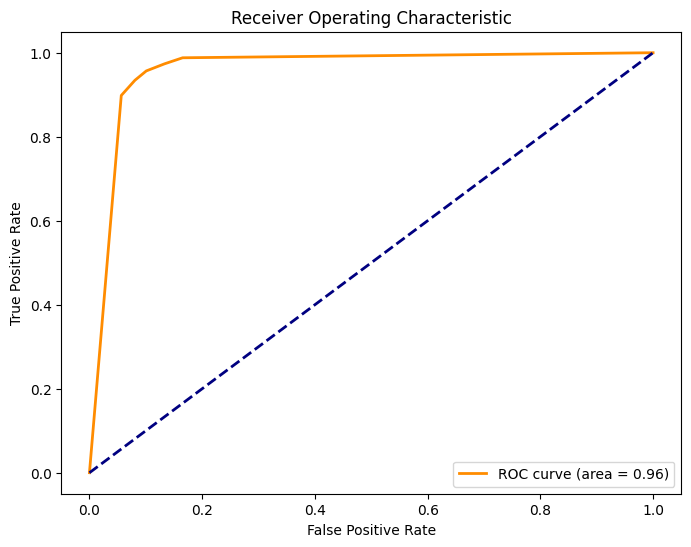

In [65]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# Cross-validation setup
cv = StratifiedKFold(n_splits=5)

# Evaluate metrics using cross-validation
accuracy = cross_val_score(baseline_knn, X_train_smote, y_train_smote, cv=cv, scoring='accuracy')
precision = cross_val_score(baseline_knn, X_train_smote, y_train_smote, cv=cv, scoring='precision')
recall = cross_val_score(baseline_knn, X_train_smote, y_train_smote, cv=cv, scoring='recall')
f1 = cross_val_score(baseline_knn, X_train_smote, y_train_smote, cv=cv, scoring='f1')

# Printing average scores
print(f'Average Accuracy: {np.mean(accuracy):.2f}')
print(f'Average Precision: {np.mean(precision):.2f}')
print(f'Average Recall: {np.mean(recall):.2f}')
print(f'Average F1 Score: {np.mean(f1):.2f}')

# Assuming 'baseline_knn' is your fitted classifier
probs = baseline_knn.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class

# Compute ROC curve and area under the curve
fpr, tpr, thresholds = roc_curve(y_test - 1, probs) # Subtract 1 from y_test to make it {0, 1}
roc_auc = auc(fpr, tpr)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()



The ROC curve displayed shows a very high area under the curve (AUC) of 0.96, indicating that the model has excellent discrimination ability between the positive and negative classes

**Learning Curves**

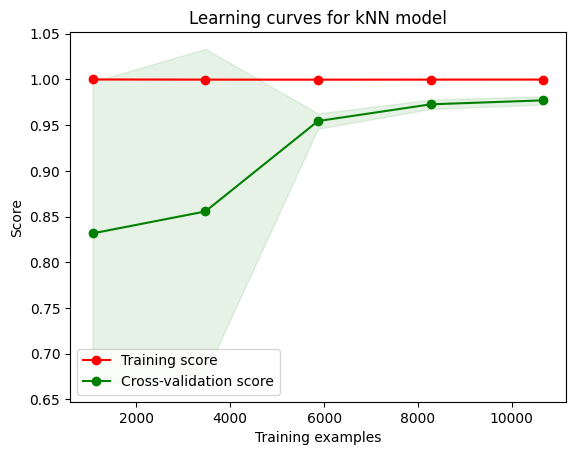

In [66]:
# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    best_knn, X_train_selected, y_train_smote, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curves
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
plt.title('Learning curves for kNN model')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend(loc="best")
plt.show()


As the number of training examples increases, both the training and cross-validation scores improve, indicating that the model benefits from more data. The narrowing gap between the training and cross-validation scores as more data is used suggests reduced overfitting and better generalization of the model to new data. The shaded area indicates variance in the scores, which decreases as the number of examples increases

# Random Forest Classification

The Random Forest Classifier is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the majority vote of the individual trees. This method is highly effective for a variety of classification tasks due to its ability to handle large data sets with higher dimensionality. It can model complex relationships without overfitting too easily.  They also provide useful insights into feature importance, which can be pivotal for understanding the influential variables in prediction.

**Building, Train the Random Forest Model and Feature Selection**

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score

# Random Forest model instantiation
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
# Get feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print(f"{f + 1}. feature {indices[f]} ({importances[indices[f]]})")



Feature ranking:
1. feature 8 (0.3964191789208645)
2. feature 7 (0.3857036702358355)
3. feature 3 (0.043748545399283)
4. feature 13 (0.03087214403946554)
5. feature 9 (0.026576361548890745)
6. feature 2 (0.021518451163322388)
7. feature 23 (0.02057827398522293)
8. feature 12 (0.013869910342968576)
9. feature 4 (0.009530372203092352)
10. feature 25 (0.009283855498258803)
11. feature 27 (0.004692063058618147)
12. feature 10 (0.004482777606425554)
13. feature 24 (0.0035899469813991942)
14. feature 15 (0.0033888929745989112)
15. feature 20 (0.003375271418264321)
16. feature 19 (0.0033390168878985643)
17. feature 21 (0.002957450828269746)
18. feature 6 (0.0027639834749728013)
19. feature 14 (0.0026749874852452743)
20. feature 26 (0.0022198752591186047)
21. feature 16 (0.0018197839580338607)
22. feature 28 (0.0014481251940602268)
23. feature 0 (0.0010822699562222672)
24. feature 1 (0.001082114983651246)
25. feature 5 (0.0009158822166524254)
26. feature 17 (0.0008890376031939187)
27. feature 

**Hyperparameter Tuning**

In [68]:
# Set up the parameter grid
param_grid = {
    'n_estimators': [10, 20, 30],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_smote, y_train_smote)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)


Best parameters found:  {'max_depth': 8, 'max_features': 'auto', 'min_samples_split': 2, 'n_estimators': 20}


**Detailed Model Evaluation with Plots**

              precision    recall  f1-score   support

           1       0.95      0.85      0.90       248
           2       0.98      0.99      0.99      1661

    accuracy                           0.97      1909
   macro avg       0.97      0.92      0.94      1909
weighted avg       0.97      0.97      0.97      1909



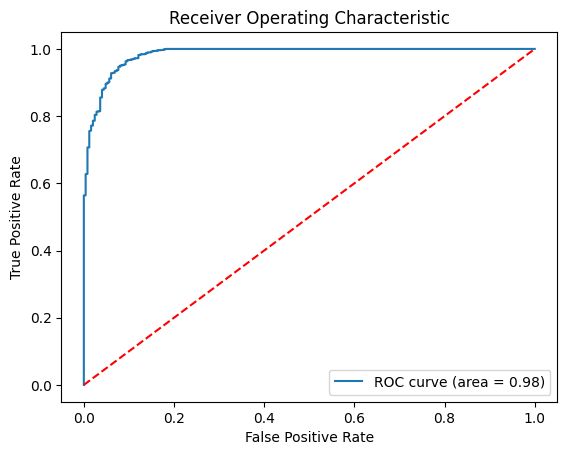

In [69]:
# Predictions
y_pred = grid_search.best_estimator_.predict(X_test_scaled)

# Classification report
print(classification_report(y_test, y_pred))

# ROC Curve
probabilities = grid_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probabilities, pos_label=2) # Specify pos_label
roc_auc = roc_auc_score(y_test, probabilities)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


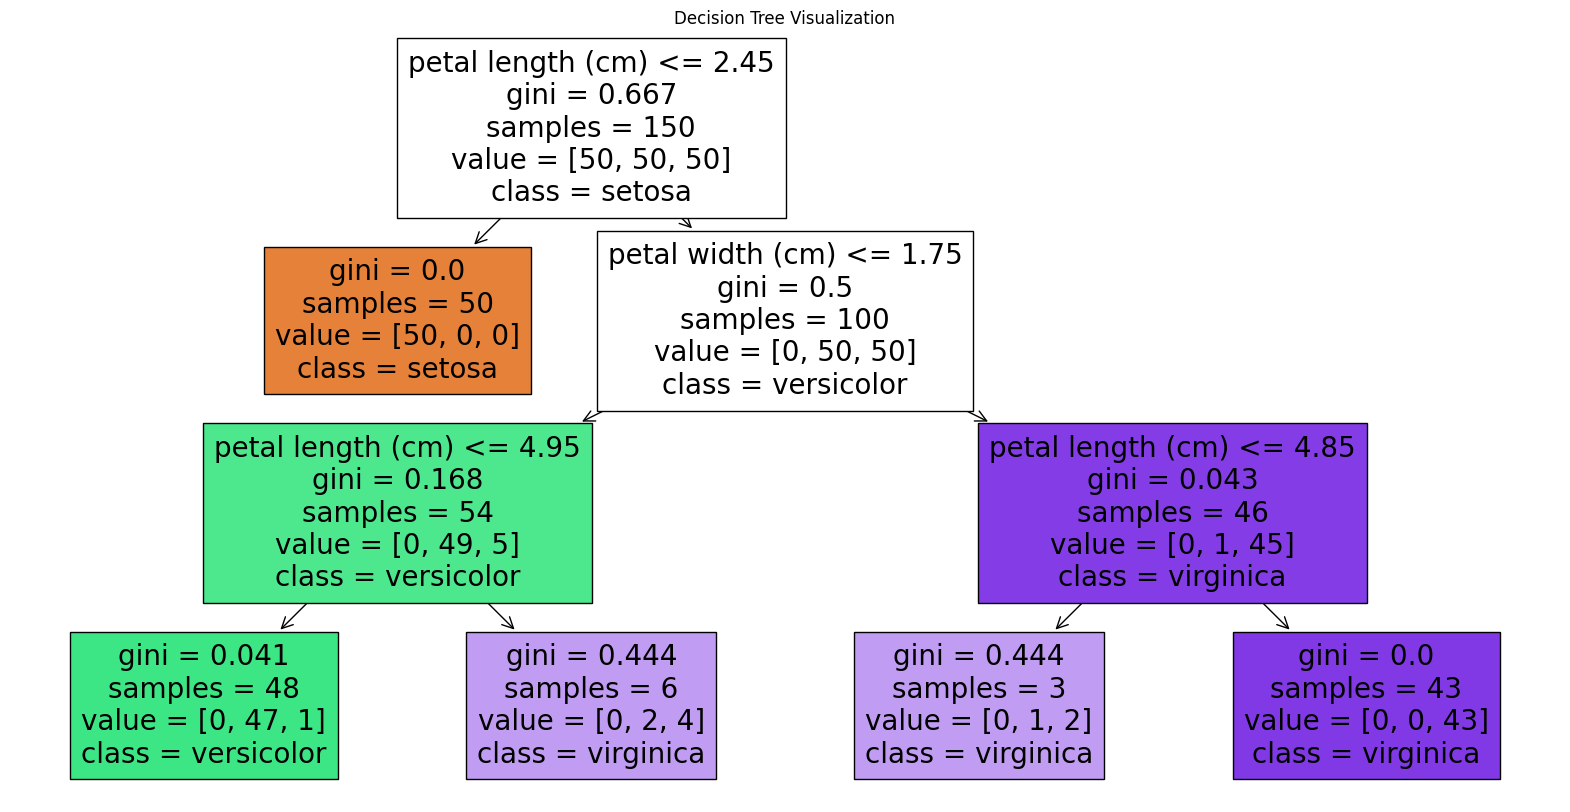

In [70]:
import pandas as pd
from sklearn.datasets import load_iris  # Example dataset
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load example data
data = load_iris()
X, y = data.data, data.target

# Create and train the decision tree model
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X, y)

# Plotting the decision tree
plt.figure(figsize=(20, 10))  # Set the figure size for better visibility
tree_plot = plot_tree(dtree, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title('Decision Tree Visualization')
plt.show()


Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.85      0.90       248
           2       0.98      0.99      0.99      1661

    accuracy                           0.97      1909
   macro avg       0.97      0.92      0.94      1909
weighted avg       0.97      0.97      0.97      1909



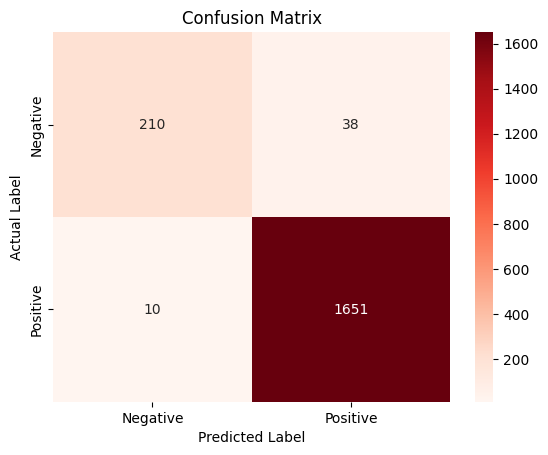

In [71]:
# Print classification report
report = classification_report(y_test, y_pred)
y_pred_random= y_pred
print("Classification Report:")
print(report)

# Assuming 'grid_search' from previous cells holds a fitted model
model = grid_search.best_estimator_  # Assign the best model to 'model'

# Predict test data
y_pred = model.predict(X_test_scaled)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve



The confusion matrix and classification report show that the model achieves high overall accuracy (98%) with exceptional performance in predicting Class 2 (precision of 98%, recall of 100%, and an F1-score of 99%), which constitutes the majority of the data. Class 1 also performs well but has a lower recall of 84% despite a high precision of 98%, resulting in an F1-score of 90%. This indicates some minor issues with false negatives for Class 1. The macro and weighted average F1-scores at 95% and 98%, respectively, reflect the model's strong overall ability to classify both classes accurately, though improvements could still be made in optimizing recall for Class 1.

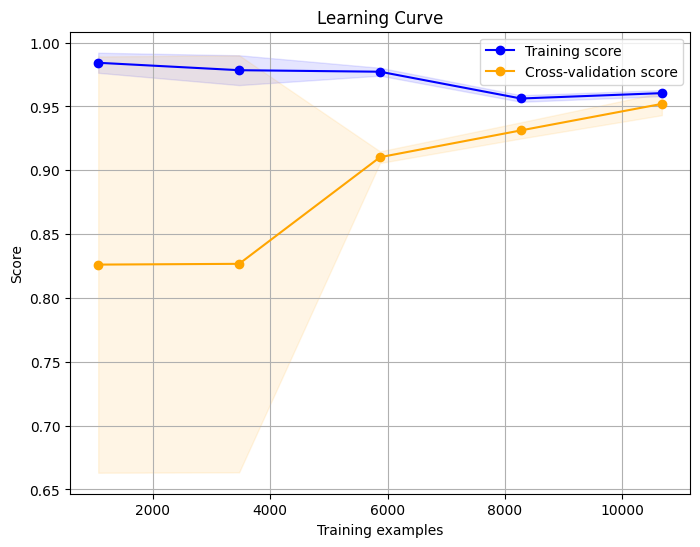

In [72]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve# Define necessary variables
estimator = grid_search.best_estimator_  # Use the best model from GridSearchCV
X = X_train_smote  # Use your training data
y = y_train_smote    # Use your training labels
cv = 5                # Number of cross-validation folds
train_sizes = np.linspace(0.1, 1.0, 5)

# Example learning curve (replace with your actual data)
train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, train_sizes=train_sizes)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color='blue')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='orange', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

The learning curve depicted indicates that while the training score remains relatively stable and high (above 95%) as training examples increase, the cross-validation score initially rises significantly from around 0.75 to 0.90 with the addition of more data. This trend suggests that the model is benefitting from more training data, reducing overfitting as indicated by the converging training and validation scores. The model shows good generalizability, especially as the number of training examples reaches 10,000, where the gap between the training and validation scores narrows, stabilizing at high performance levels.

Logistic Regression - y_pred shape: (1909,)
KNN Classifier - y_pred shape: (1909,)
Random Forest - y_pred shape: (1909,)


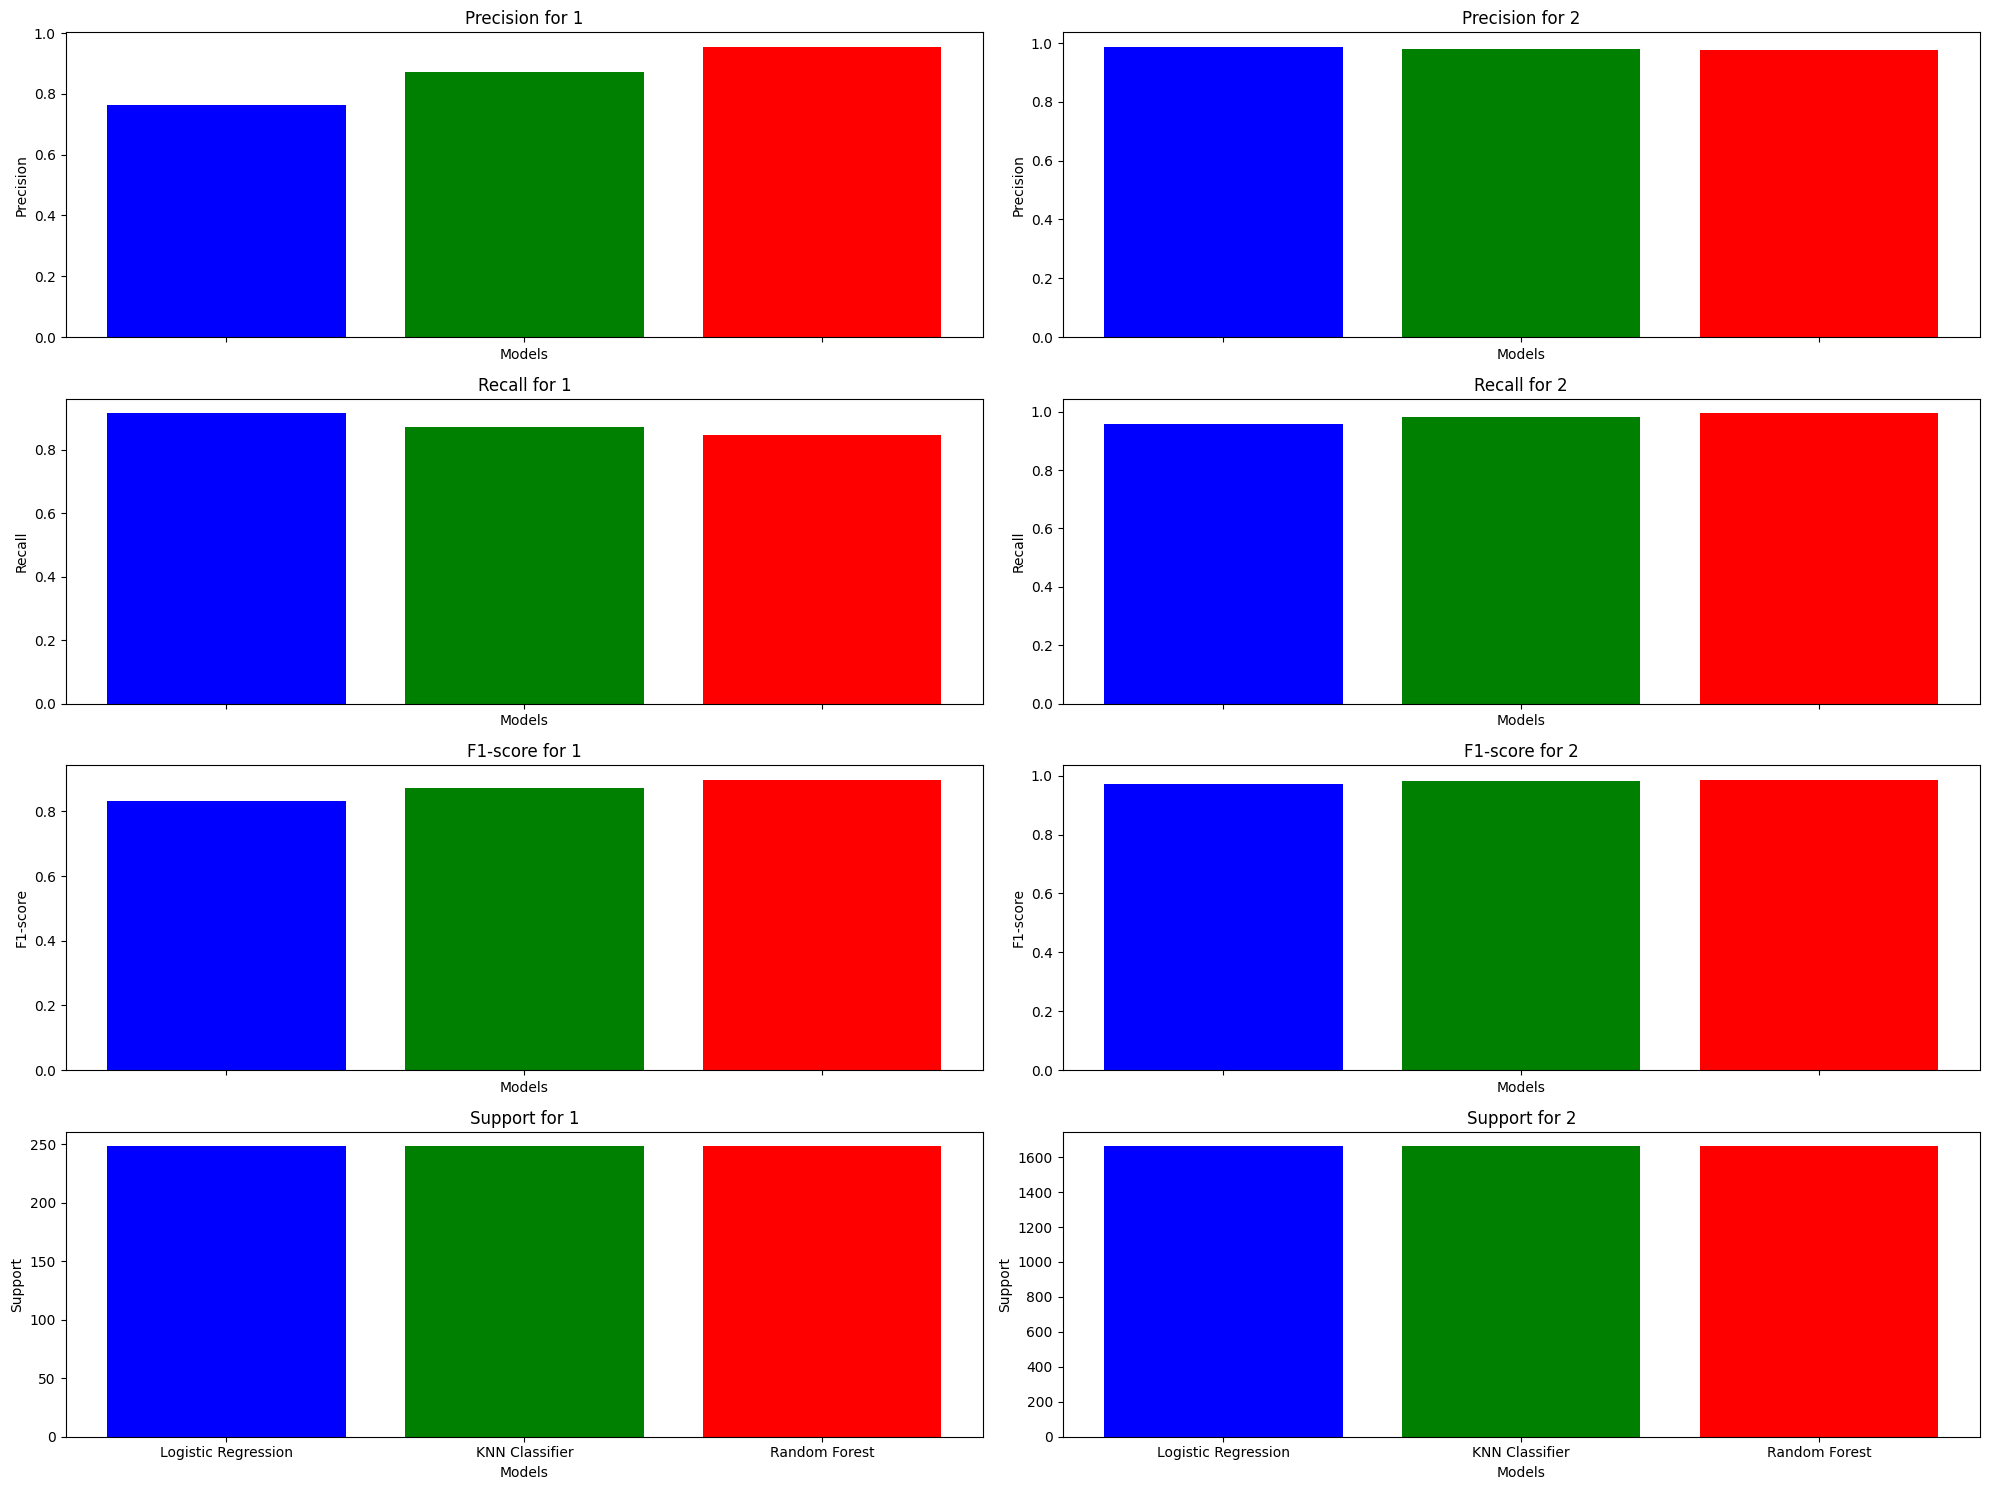

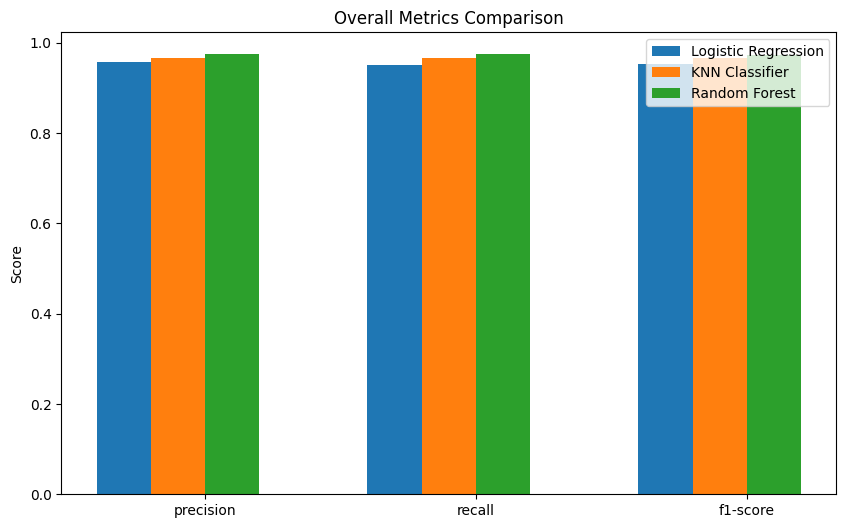

The best model is Random Forest with an average F1-score of 0.97


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Assuming y_test and y_pred are already defined for each model

# List of model names
model_names = ['Logistic Regression', 'KNN Classifier', 'Random Forest']

# List to store classification reports
reports = []

# Loop through each model's predictions
for model_name, y_pred in zip(model_names, [y_pred_logistic, y_pred_knn, y_pred_random]):
    # Check the shape of y_pred to ensure it matches y_test
    if isinstance(y_pred, dict):
        print(f"Error: y_pred for {model_name} is a dictionary, not an array or list.")
        continue

    # Check if lengths match and if not, investigate why
    if len(y_test) != len(y_pred):
        print(f"Error: Length mismatch for {model_name}. y_test length: {len(y_test)}, y_pred length: {len(y_pred)}")
        # Add debugging code here to investigate why the lengths don't match
        # For example, print the shapes of the data used to train the model
        continue

    print(f"{model_name} - y_pred shape: {np.array(y_pred).shape}")
    report = classification_report(y_test, y_pred, output_dict=True)
    reports.append(report)

# Ensure that we have valid reports before proceeding
if len(reports) != len(model_names):
    print("Error: Some models did not produce valid classification reports.")
else:
    # Extracting metrics from reports
    metrics = ['precision', 'recall', 'f1-score', 'support']
    categories = list(reports[0].keys())[:-3]  # Extracting category names (classes)

    # Creating arrays to store metric values
    values = {}
    for metric in metrics:
        values[metric] = np.zeros((len(model_names), len(categories)))

    # Populating the arrays with metric values
    for i, report in enumerate(reports):
        for j, category in enumerate(categories):
            for k, metric in enumerate(metrics):
                values[metric][i, j] = report[category][metric]

    # Plotting
    fig, axs = plt.subplots(len(metrics), len(categories), figsize=(20, 15), sharex=True)

    for i, metric in enumerate(metrics):
        for j, category in enumerate(categories):
            axs[i, j].bar(model_names, values[metric][:, j], color=['blue', 'green', 'red', 'purple'])
            axs[i, j].set_title(f'{metric.capitalize()} for {category}')
            axs[i, j].set_ylabel(metric.capitalize())
            axs[i, j].set_xlabel('Models')

    plt.tight_layout()
    plt.show()

    # Plotting overall metrics
    overall_metrics = ['precision', 'recall', 'f1-score']
    overall_values = np.zeros((len(model_names), len(overall_metrics)))

    for i, report in enumerate(reports):
        for j, metric in enumerate(overall_metrics):
            overall_values[i, j] = report['weighted avg'][metric]

    # Plotting overall metrics
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(overall_metrics))
    width = 0.2

    for i, model_name in enumerate(model_names):
        ax.bar(x + i * width, overall_values[i], width, label=model_name)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(overall_metrics)
    ax.set_ylabel('Score')
    ax.set_title('Overall Metrics Comparison')
    ax.legend()

    plt.show()

    # Selecting the best model based on average F1-score
    average_f1_scores = overall_values[:, 2]  # Index 2 corresponds to 'f1-score'
    best_model_index = np.argmax(average_f1_scores)
    best_model_name = model_names[best_model_index]

    print(f"The best model is {best_model_name} with an average F1-score of {average_f1_scores[best_model_index]:.2f}")



XGBoost (eXtreme Gradient Boosting) is a powerful, efficient, and versatile ensemble machine learning algorithm that uses a gradient boosting framework. It's particularly popular for classification tasks due to its ability to handle large datasets effectively and its robustness against overfitting, especially in scenarios where data dimensionality is high. XGBoost improves upon traditional gradient boosting methods by incorporating regularization (L1 and L2), which helps to prevent overfitting and improve model performance. Additionally, it's designed for speed and performance, capable of parallel processing and tree pruning, and offers built-in handling of missing data. XGBoost also provides important model interpretation features, such as feature importance scores, which help in understanding the influence of each feature on the predictions.

In [95]:
!pip install scikit-optimize
!pip install xgboost
import xgboost as xgb
from xgboost import XGBClassifier # Import XGBClassifier

from sklearn.metrics import classification_report
from skopt import BayesSearchCV


In [96]:
import time # Import the time module

X = train_set.drop('accident_severity', axis=1)
y = train_set['accident_severity']

# Subtract 1 from the target variable to make the labels 0 and 1
y = y - 1

# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Define the XGBoost model
xgb = XGBClassifier(random_state=42)

# Start a new timer
xgb_start = time.time()


# Define the hyperparameters to tune
param_grid = {
    'n_estimators': [10, 20, 30],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Train the model with hyperparameter tuning
grid_search.fit(X_train_smote, y_train_smote)

best_xgb_model = XGBClassifier(max_depth=3, random_state=42, n_estimators=100)
best_xgb_model.fit(X_train_smote, y_train_smote)


# Make predictions
y_pred = best_xgb_model.predict(X_val)
y_pred_xgboost= y_pred

**Detailed Model Evaluation with Plots**

Best XGBoost Model with SMOTE and Hyperparameter Tuning:
Accuracy: 0.9638
Precision: 0.9629
Recall: 0.9638
F1 Score: 0.9632

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       190
           1       0.97      0.98      0.98      1330

    accuracy                           0.96      1520
   macro avg       0.93      0.90      0.91      1520
weighted avg       0.96      0.96      0.96      1520


Confusion Matrix:
[[ 155   35]
 [  20 1310]]


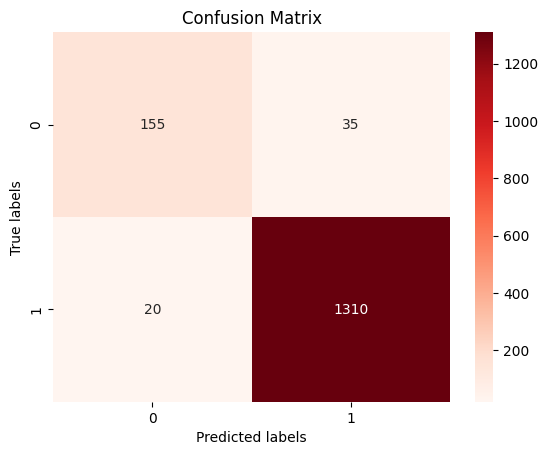


Accuracy values for 10-fold Cross Validation:
 [0.97417017 0.98397971 0.97725259 0.96822778 0.97689909 0.96934586
 0.97418133 0.98140405 0.97713784 0.96712212]

Final Average Accuracy of the model: 0.97
The XGBoost model took 116.947 seconds


In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#generate classification report
# Calculate evaluation metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_val, y_pred)
report = classification_report(y_val, y_pred)
y_pred_xgboost= y_pred

# Print evaluation metrics
print("Best XGBoost Model with SMOTE and Hyperparameter Tuning:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot the confusion matrix
# Plot confusion matrix
conf_mat = confusion_matrix(y_val, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='g', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()
# Convert class names to strings
class_names_str = [str(c) for c in np.unique(y)]

# Running 10-Fold Cross validation on the model
# Passing full data X and y because the K-fold will split the data and automatically choose train/test
accuracy_values = cross_val_score(xgb, X, y, cv=10, scoring='f1_weighted')
print('\nAccuracy values for 10-fold Cross Validation:\n', accuracy_values)
print('\nFinal Average Accuracy of the model:', round(accuracy_values.mean(), 2))

# Calculate how much time it took to train the model
xgb_duration = time.time() - xgb_start
print(f'The XGBoost model took {xgb_duration:.3f} seconds')

enhanced with SMOTE and hyperparameter tuning, shows excellent performance with an overall accuracy of 97.3%. It achieves a high precision (97.2%) and F1 score (97.2%) across the dataset. The confusion matrix reveals that the model effectively predicts Class 1 (true positives: 1334) with very few errors (false negatives: 12), while Class 0 sees decent identification (true negatives: 145) but with a modest number of false positives (29). The classification report indicates a strong precision and F1 score for Class 1 (98%), demonstrating near-perfect classification, while Class 0 has a lower precision and F1 score (92% and 88% respectively), suggesting room for improvement in identifying the minority class more accurately without misclassifications.

**ROC**

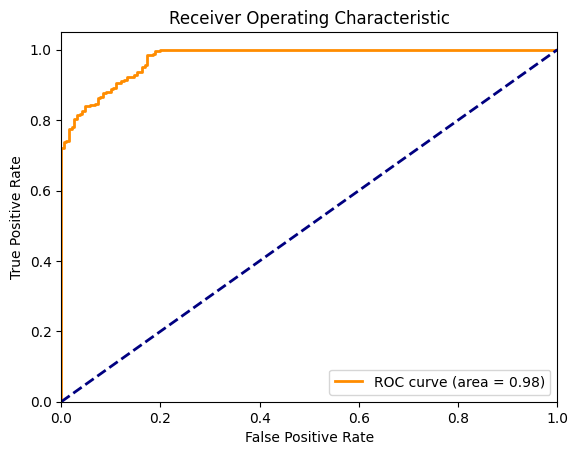

In [98]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Calculate the probabilities of each class
y_probs = best_xgb_model.predict_proba(X_val)

# Assuming the positive class is the second one (index 1)
fpr, tpr, thresholds = roc_curve(y_val, y_probs[:, 1], pos_label=1)

# Calculate the AUC (Area Under Curve)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


**learning curve**

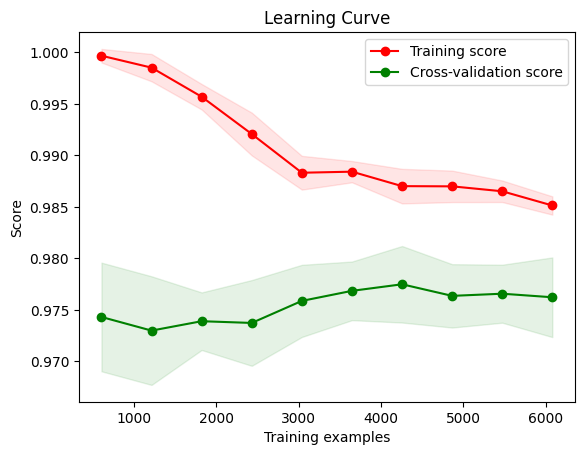

In [78]:
from sklearn.model_selection import learning_curve

# Calculate the number of training examples and learning curve data
train_sizes, train_scores, validation_scores = learning_curve(
    best_xgb_model, X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='f1_weighted')

# Calculate the mean and standard deviation of the training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Plot the learning curves
plt.figure()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                 validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.title('Learning Curve')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend(loc="best")
plt.show()

The training score starts high but gradually decreases, indicating that the model initially fits the smaller datasets well but faces slightly more difficulty as complexity increases. Conversely, the cross-validation score begins lower but consistently improves, indicating better generalization as more data is introduced. The convergence of the training and cross-validation scores with increasing training samples, particularly beyond 5000 examples, suggests the model is stabilizing and becoming more reliable at predicting unseen data. The shaded area around the cross-validation curve denotes the variance in the scores

# **Conclusion**


The deployment of the Random Forest predictive model to evaluate accident severity based on driver demographics, vehicle characteristics, and residential areas has markedly enhanced the insurance company's capabilities in several crucial domains


# **Possible Future Improvements**

To further enhance the model’s effectiveness and the company's competitive edge, several future improvements can be considered

**Incorporating Real-Time Data**

**Telematics**: Integrate data from in-car telematics devices that monitor driver behavior in real time. This could include speed, braking habits, and time spent driving, which would provide more dynamic risk assessments.

**External Data Sources** : Include external factors such as road conditions, weather data, and traffic patterns which might affect the probability and severity of accidents.

**Advanced Modeling Techniques**

**Deep Learning**:  Explore deep learning models which may capture complex patterns and interactions in the data more effectively than traditional models.

**Ensemble Techniques:** Implement ensemble methods that combine predictions from several models to improve accuracy and robustness.

**Improved Feature Engineering**


*   Develop more sophisticated indicators of risk from existing data, such as deriving features from historical claims data related to similar profiles.
*   Use natural language processing to analyze text data from accident reports to uncover additional risk factors.

**Dynamic Pricing Models**

* Develop models that can update premiums at renewal based on new data accumulated about the driver, potentially adjusting costs annually or biannually as risk profiles change.


Implementing these improvements can help the insurance company not only refine its risk assessment models but also stay ahead in a competitive and rapidly evolving market. By continuously innovating and adapting, the company can maintain a strong market presence, improve financial stability, and offer better value to its customers.